# NLP Project: Sentiment & Entity Analysis on Customer Feedback #

## Objective:
To analyze customer feedback using Natural Language Processing techniques.
This includes identifying sentiment, extracting entities, and visualizing key text features.

#### Install & Import Libraries

In [3]:
import nltk
import spacy
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag, ne_chunk
from nltk.chunk import tree2conlltags
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import string
from collections import Counter

# Downloads
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('omw-1.4')

nlp = spacy.load("en_core_web_sm")
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\NSTIW\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\NSTIW\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\NSTIW\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\NSTIW\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\NSTIW\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\NSTIW\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-

#### Sample Dataset

In [5]:
feedback = [
    "The service was excellent and the staff were friendly.",
    "I am disappointed with the product. It broke after a week!",
    "Customer support was helpful and resolved my issue quickly.",
    "Worst experience ever. I will never buy from here again.",
    "Apple released a new iPhone today in California."
]


#### Word Tokenization

In [7]:
print("🔹 Step 1: Word Tokenization\n")
for text in feedback:
    print(f"Text: {text}")
    print("Tokens:", word_tokenize(text), "\n")


🔹 Step 1: Word Tokenization

Text: The service was excellent and the staff were friendly.
Tokens: ['The', 'service', 'was', 'excellent', 'and', 'the', 'staff', 'were', 'friendly', '.'] 

Text: I am disappointed with the product. It broke after a week!
Tokens: ['I', 'am', 'disappointed', 'with', 'the', 'product', '.', 'It', 'broke', 'after', 'a', 'week', '!'] 

Text: Customer support was helpful and resolved my issue quickly.
Tokens: ['Customer', 'support', 'was', 'helpful', 'and', 'resolved', 'my', 'issue', 'quickly', '.'] 

Text: Worst experience ever. I will never buy from here again.
Tokens: ['Worst', 'experience', 'ever', '.', 'I', 'will', 'never', 'buy', 'from', 'here', 'again', '.'] 

Text: Apple released a new iPhone today in California.
Tokens: ['Apple', 'released', 'a', 'new', 'iPhone', 'today', 'in', 'California', '.'] 



#### Lemmatization vs Stemming

In [9]:
text = "running runs runner"
tokens = word_tokenize(text)
print("\n🔹 Step 2: Lemmatization vs Stemming")
print("Lemmatized:", [lemmatizer.lemmatize(w) for w in tokens])
print("Stemmed:", [stemmer.stem(w) for w in tokens])



🔹 Step 2: Lemmatization vs Stemming
Lemmatized: ['running', 'run', 'runner']
Stemmed: ['run', 'run', 'runner']


#### Named Entity Recognition (NER)

In [11]:
print("\n🔹 Step 3: Named Entity Recognition (NER)")
for text in feedback:
    doc = nlp(text)
    for ent in doc.ents:
        print(ent.text, "→", ent.label_)



🔹 Step 3: Named Entity Recognition (NER)
a week → DATE
Apple → ORG
today → DATE
California → GPE


#### Sentiment Analysis

In [13]:
print("\n🔹 Step 4: Sentiment Analysis")
for text in feedback:
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    print(f"Text: {text}")
    print("Polarity:", polarity)
    print("Sentiment:", "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral", "\n")



🔹 Step 4: Sentiment Analysis
Text: The service was excellent and the staff were friendly.
Polarity: 0.6875
Sentiment: Positive 

Text: I am disappointed with the product. It broke after a week!
Polarity: -0.9375
Sentiment: Negative 

Text: Customer support was helpful and resolved my issue quickly.
Polarity: 0.3333333333333333
Sentiment: Positive 

Text: Worst experience ever. I will never buy from here again.
Polarity: -1.0
Sentiment: Negative 

Text: Apple released a new iPhone today in California.
Polarity: 0.13636363636363635
Sentiment: Positive 



#### spaCy POS Tagging

In [15]:
print("\n🔹 Step 5: spaCy Tokenization and POS Tags")
for text in feedback:
    doc = nlp(text)
    for token in doc:
        print(f"{token.text} → {token.pos_}")
    print()



🔹 Step 5: spaCy Tokenization and POS Tags
The → DET
service → NOUN
was → AUX
excellent → ADJ
and → CCONJ
the → DET
staff → NOUN
were → AUX
friendly → ADJ
. → PUNCT

I → PRON
am → AUX
disappointed → VERB
with → ADP
the → DET
product → NOUN
. → PUNCT
It → PRON
broke → VERB
after → ADP
a → DET
week → NOUN
! → PUNCT

Customer → NOUN
support → NOUN
was → AUX
helpful → ADJ
and → CCONJ
resolved → VERB
my → PRON
issue → NOUN
quickly → ADV
. → PUNCT

Worst → ADJ
experience → NOUN
ever → ADV
. → PUNCT
I → PRON
will → AUX
never → ADV
buy → VERB
from → ADP
here → ADV
again → ADV
. → PUNCT

Apple → PROPN
released → VERB
a → DET
new → ADJ
iPhone → PROPN
today → NOUN
in → ADP
California → PROPN
. → PUNCT



#### Entity Analysis Summary

In [17]:
entity_labels = []
for text in feedback:
    doc = nlp(text)
    entity_labels += [ent.label_ for ent in doc.ents]

print("\n🔹 Step 6: Entity Types Summary")
print("Entity Counts:", Counter(entity_labels))



🔹 Step 6: Entity Types Summary
Entity Counts: Counter({'DATE': 2, 'ORG': 1, 'GPE': 1})


#### Basic NLP Cleaning

In [19]:
def clean_text(text):
    tokens = word_tokenize(text.lower())
    return [w for w in tokens if w not in stop_words and w not in string.punctuation]

print("\n🔹 Step 7: Cleaned Tokens (no stopwords or punctuation)")
for text in feedback:
    print("Cleaned:", clean_text(text))



🔹 Step 7: Cleaned Tokens (no stopwords or punctuation)
Cleaned: ['service', 'excellent', 'staff', 'friendly']
Cleaned: ['disappointed', 'product', 'broke', 'week']
Cleaned: ['customer', 'support', 'helpful', 'resolved', 'issue', 'quickly']
Cleaned: ['worst', 'experience', 'ever', 'never', 'buy']
Cleaned: ['apple', 'released', 'new', 'iphone', 'today', 'california']


#### Text Preprocessing Pipeline (Clean + Lemmatize)

In [21]:
def preprocess_pipeline(text):
    tokens = clean_text(text)
    return [lemmatizer.lemmatize(w) for w in tokens]

print("\n🔹 Step 8: Preprocessed Tokens (cleaned + lemmatized)")
for text in feedback:
    print("Processed:", preprocess_pipeline(text))



🔹 Step 8: Preprocessed Tokens (cleaned + lemmatized)
Processed: ['service', 'excellent', 'staff', 'friendly']
Processed: ['disappointed', 'product', 'broke', 'week']
Processed: ['customer', 'support', 'helpful', 'resolved', 'issue', 'quickly']
Processed: ['worst', 'experience', 'ever', 'never', 'buy']
Processed: ['apple', 'released', 'new', 'iphone', 'today', 'california']


#### Syntactic Analysis (Dependency Parsing)

In [23]:
print("\n🔹 Step 9: Dependency Parsing")
for text in feedback:
    doc = nlp(text)
    for token in doc:
        print(f"{token.text} - {token.dep_} → {token.head.text}")
    print()



🔹 Step 9: Dependency Parsing
The - det → service
service - nsubj → was
was - ROOT → was
excellent - acomp → was
and - cc → was
the - det → staff
staff - nsubj → were
were - conj → was
friendly - acomp → were
. - punct → were

I - nsubjpass → disappointed
am - auxpass → disappointed
disappointed - ROOT → disappointed
with - prep → disappointed
the - det → product
product - pobj → with
. - punct → disappointed
It - nsubj → broke
broke - ROOT → broke
after - prep → broke
a - det → week
week - pobj → after
! - punct → broke

Customer - compound → support
support - nsubj → was
was - ROOT → was
helpful - acomp → was
and - cc → was
resolved - conj → was
my - poss → issue
issue - dobj → resolved
quickly - advmod → resolved
. - punct → was

Worst - amod → experience
experience - ROOT → experience
ever - advmod → experience
. - punct → experience
I - nsubj → buy
will - aux → buy
never - neg → buy
buy - ROOT → buy
from - prep → buy
here - pcomp → from
again - advmod → buy
. - punct → buy

Apple 

#### Chunking (IOB Format)

In [25]:
print("\n🔹 Step 10: Chunking (IOB Tags)")
for text in feedback:
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    chunked = ne_chunk(tags)
    print(tree2conlltags(chunked), "\n")



🔹 Step 10: Chunking (IOB Tags)
[('The', 'DT', 'O'), ('service', 'NN', 'O'), ('was', 'VBD', 'O'), ('excellent', 'JJ', 'O'), ('and', 'CC', 'O'), ('the', 'DT', 'O'), ('staff', 'NN', 'O'), ('were', 'VBD', 'O'), ('friendly', 'RB', 'O'), ('.', '.', 'O')] 

[('I', 'PRP', 'O'), ('am', 'VBP', 'O'), ('disappointed', 'JJ', 'O'), ('with', 'IN', 'O'), ('the', 'DT', 'O'), ('product', 'NN', 'O'), ('.', '.', 'O'), ('It', 'PRP', 'O'), ('broke', 'VBD', 'O'), ('after', 'IN', 'O'), ('a', 'DT', 'O'), ('week', 'NN', 'O'), ('!', '.', 'O')] 

[('Customer', 'NNP', 'B-GPE'), ('support', 'NN', 'O'), ('was', 'VBD', 'O'), ('helpful', 'JJ', 'O'), ('and', 'CC', 'O'), ('resolved', 'VBD', 'O'), ('my', 'PRP$', 'O'), ('issue', 'NN', 'O'), ('quickly', 'RB', 'O'), ('.', '.', 'O')] 

[('Worst', 'NNP', 'B-GPE'), ('experience', 'NN', 'O'), ('ever', 'RB', 'O'), ('.', '.', 'O'), ('I', 'PRP', 'O'), ('will', 'MD', 'O'), ('never', 'RB', 'O'), ('buy', 'VB', 'O'), ('from', 'IN', 'O'), ('here', 'RB', 'O'), ('again', 'RB', 'O'), ('.

#### Bag of Words Model

In [27]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(feedback)

print("\n🔹 Step 11: Bag of Words")
print("Vocabulary:", vectorizer.get_feature_names_out())
print("Matrix:\n", X.toarray())



🔹 Step 11: Bag of Words
Vocabulary: ['after' 'again' 'am' 'and' 'apple' 'broke' 'buy' 'california' 'customer'
 'disappointed' 'ever' 'excellent' 'experience' 'friendly' 'from'
 'helpful' 'here' 'in' 'iphone' 'issue' 'it' 'my' 'never' 'new' 'product'
 'quickly' 'released' 'resolved' 'service' 'staff' 'support' 'the' 'today'
 'was' 'week' 'were' 'will' 'with' 'worst']
Matrix:
 [[0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 2 0 1 0 1
  0 0 0]
 [1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0
  0 1 0]
 [0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 0 1 0 0
  0 0 0]
 [0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
  1 0 1]
 [0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0
  0 0 0]]


#### Spam Detection System (Naive Bayes)

In [29]:
spam_data = [
    ("Win $1000 now!", "spam"),
    ("Hello, how are you?", "ham"),
    ("Lowest prices on meds", "spam"),
    ("Let's catch up soon!", "ham")
]

texts, labels = zip(*spam_data)
vec = TfidfVectorizer()
X = vec.fit_transform(texts)

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3)
model = MultinomialNB()
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("\n🔹 Step 12: Spam Detection Accuracy")
print("Accuracy:", accuracy_score(y_test, preds))



🔹 Step 12: Spam Detection Accuracy
Accuracy: 0.0


#### Sentence Tokenization

In [31]:
print("\n🔹 Step 13: Sentence Tokenization")
for text in feedback:
    print(sent_tokenize(text))



🔹 Step 13: Sentence Tokenization
['The service was excellent and the staff were friendly.']
['I am disappointed with the product.', 'It broke after a week!']
['Customer support was helpful and resolved my issue quickly.']
['Worst experience ever.', 'I will never buy from here again.']
['Apple released a new iPhone today in California.']


#### Visulization

#### Sample Texts:

In [59]:
text1 = "The service was excellent and the staff were friendly."
text2 = "I am disappointed with the product. It broke after a week!"

#### Word Cloud for Each Text

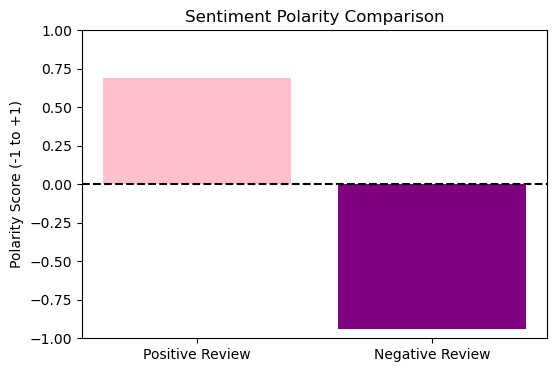

In [63]:
import matplotlib.pyplot as plt
from textblob import TextBlob

# Texts
texts = [text1, text2]
labels = ["Positive Review", "Negative Review"]
polarities = [TextBlob(t).sentiment.polarity for t in texts]

# Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(labels, polarities, color=['pink', 'purple'])
plt.title("Sentiment Polarity Comparison")
plt.ylabel("Polarity Score (-1 to +1)")
plt.ylim(-1, 1)
plt.axhline(0, color='black', linestyle='--')
plt.show()


#### POS Tag Frequency (Bar Chart)

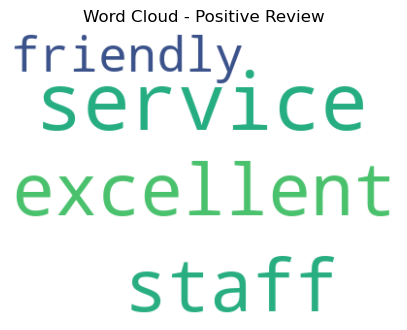

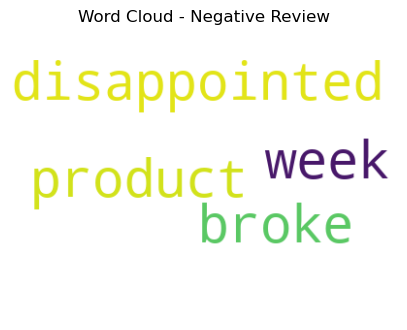

In [65]:
from wordcloud import WordCloud

# Word clouds
for i, text in enumerate(texts):
    wc = WordCloud(width=400, height=300, background_color='white').generate(text)
    plt.figure(figsize=(5, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud - {labels[i]}")
    plt.show()
